In [1]:
import logic.pulsed.pulse_objects as po
from logic.pulsed.sampling_functions import SamplingFunctions as SF
import time
import matplotlib.pyplot as plt
import pickle
import datetime
from tqdm import tqdm
from matplotlib.pyplot import cm
import numpy as np
from hardware.timetagger_counter import HWRecorderMode
pjl = pulsedjupyterlogic_AWG #Make sure the Logic is started in the Qudi manager!!!!

In [16]:
def setup_autoapproach():
    #configuration of autoapproach settings
    # for HFAmpl signal

    threshold = spm._dev.base.getParameter(spm._dev.base.getConst('ID_REG_SETP_DISP')) / 1e7
    spm._dev.aap.setAApThreshold(threshold)

    # dF     8
    # HFAmpl       13
    input_signal = spm._dev.base.getParameter(spm._dev.base.getConst('ID_REG_INPUT'))
    threshold_cond = 1 if input_signal==13 else 0        
    spm._dev.aap.setAApStopCondition(threshold_cond) # [0, 1] >threshold/<threshold
    spm._dev.aap.setAApStepsPerApproach(0)

    spm._dev.aap.setAApAproachMode(1) # [0, 1] Ramp/Loop
    spm._dev.aap.setAApModeAfter(0) # [0, 1, 2] On/Retract/Off

def get_pos(reps=5):
    pos = 0
    for i in range(reps):
        pos = pos+ spm.get_sample_pos()['Z']
        time.sleep(0.005)
    return pos/reps

def go_into_contact():
    spm._dev.base.setParameter(spm._dev.base.getConst('ID_AAP_CTRL'), 1, 0)
    while not spm.is_probe_landed():
        time.sleep(0.001)
    time.sleep(0.5)
        
def do_lift_off(lift_off_height):
    pos = get_pos()
    new_pos = pos - lift_off_height
    spm._dev.base.setParameter(spm._dev.base.getConst('ID_REG_LOOP_ON'), 0, 0)
    spm._dev.base.setParameter(spm._dev.base.getConst('ID_REG_SET_Z_M'), new_pos*1e12, 0)

def _grabASCData(chnNo, bufSize):
    while True:
            # Wait until buffer is full
        if spm._dev.base.waitForFullBuffer(chnNo) != 0:
                break
    buffer = spm._dev.base.getDataBuffer(chnNo, 0, bufSize)
    values = buffer[3][:]
    meta = buffer[4]
    phys_vals = []
    unit = spm._dev.base.getUnitVal(meta)
    scaling = 1
    if 'Milli' in unit:
        scaling = 1e-3
    for val in values:
        phys_vals.append(spm._dev.base.convValue2Phys(meta, val)*scaling)
    return np.mean(phys_vals)    
    
def get_spm_channel_data(channel="CHANADC_AFMAMPL"):
    """Look in to the header file asc500.h for all the channel names"""
    spm._dev.base.configureChannel(11, # any Number between 0 and 13.
                            spm._dev.base.getConst('CHANCONN_PERMANENT'), # How you want to the data to be triggered
                            spm._dev.base.getConst('CHANADC_AFMAMPL'), #The Channel you want to get the data from
                            1, # 0/1 -  if you want to switch on averaging
                            1e-3) # Scanner sample time [s]
    spm._dev.base.configureDataBuffering(11, 256) # chNo = same as above; bufSize = Buffersize.
    # MAKE SURE BUFFER SIZE IS GREATER THAN 128 FOR TIME TRIGGERED DATA
    return _grabASCData(11, 256)

def setup_counter(laser_pulses, max_sweeps):
    ret_val = afm_scanner_logic._counter.configure_recorder(
                mode=HWRecorderMode.GENERAL_PULSED,
                params={'laser_pulses': laser_pulses,
                        'bin_width_s': podmrlogic.bin_width_s,
                        'record_length_s': podmrlogic.record_length_s,
                        'max_counts': int(max_sweeps)} )
    
def run_measurement():
    afm_scanner_logic._counter.start_recorder(arm=True)
    #Start pulsed measurement
    afm_scanner_logic._pulsed_master_AWG.pulsedmeasurementlogic().pulsegenerator().pulser_on()
    # obtain pulsed measurement
    pulsed_meas = afm_scanner_logic._counter.get_measurements()[0] # this is the blocking statement
    afm_scanner_logic._pulsed_master_AWG.pulsedmeasurementlogic().pulsegenerator().pulser_off()
    return pulsed_meas

def multiple_formatter(denominator=2, number=np.pi, latex='\pi'):
    def gcd(a, b):
        while b:
            a, b = b, a%b
        return a
    def _multiple_formatter(x, pos):
        den = denominator
        num = np.int(np.rint(den*x/number))
        com = gcd(num,den)
        (num,den) = (int(num/com),int(den/com))
        if den==1:
            if num==0:
                return r'$0$'
            if num==1:
                return r'$%s$'%latex
            elif num==-1:
                return r'$-%s$'%latex
            else:
                return r'$%s%s$'%(num,latex)
        else:
            if num==1:
                return r'$\frac{%s}{%s}$'%(latex,den)
            elif num==-1:
                return r'$\frac{-%s}{%s}$'%(latex,den)
            else:
                return r'$\frac{%s%s}{%s}$'%(num,latex,den)
    return _multiple_formatter

class Multiple:
    def __init__(self, denominator=2, number=np.pi, latex='\pi'):
        self.denominator = denominator
        self.number = number
        self.latex = latex

    def locator(self):
        return plt.MultipleLocator(self.number / self.denominator)

    def formatter(self):
        return plt.FuncFormatter(multiple_formatter(self.denominator, self.number, self.latex))

#### Define general measurement params

In [30]:
#measurement parameters
laser_power_voltage = 0.0 #podmrlogic.laser_power_voltage

#Driving information for the first LO (SMBV)
target_freq_0 = 3.1172e9
LO_freq_0 = target_freq_0 + 100e6
power_0 = -2
pi_pulse = 114e-9 

#additional information for save tag
tip_name = 'A-P16-24'
sample = 'Tommy_2'
temperature = ''
b_field = ''
contact = 'IC'
res_freq = spm._dev.afm.getTFExcicationFrequency()
extra = f'{res_freq/1e3}kHz'

#### Load and ready Gradiometry sequence

In [31]:
Aexc = spm._dev.afm.getTFExcitationAmplitude()
res_freq = spm._dev.afm.getTFExcicationFrequency()

lift_off_height = 15e-9
lift_off_check_period = 60*5

tau = 5.112e-6

t0_start = 5e-6
t0_stop = 15e-6
t0_num = 30
laser_pulses = 4
max_sweeps = 500e3

t0_sweep_init = np.linspace(t0_start, t0_stop, t0_num)
t0_sweep = np.zeros_like(t0_sweep_init)

phase_sweeps = np.zeros_like(t0_sweep_init)

afm_scanner_logic.jupyter_meas_stop = False

setup_autoapproach()
go_into_contact()

meas_dict = {}
afm_scanner_logic._pulsed_master_AWG.pulsedmeasurementlogic().pulsegenerator().pulser_off()
setup_counter(laser_pulses, max_sweeps)

data_arr = np.zeros( (len(t0_sweep_init), 4, int(podmrlogic.record_length_s/podmrlogic.bin_width_s)) )

with tqdm(t0_sweep_init) as progress_bar:
    for i, t_0 in enumerate(progress_bar):
        pjl.initialize_ensemble(pi_pulse=pi_pulse, LO_freq_0=LO_freq_0, target_freq_0=target_freq_0, 
                                power_0=power_0, trigger_type = 'pos_edge_rearm', 
                                trigger_level0 = 400, trigger_level1 = -200)

        ret = pjl.CPMG1_gradiometry(t_0, tau)
#         ret = pjl.XY16_gradiometry(t_0, tau, 1)
        t0_sweep[i] = ret[5]

        #Lift off
        lift_off_start = 0
        if lift_off_height > 0:
            do_lift_off(lift_off_height)
            lift_off_start = time.time()

        data = run_measurement()
        data_arr[i] = data.copy()
        
        if lift_off_height > 0:
            go_into_contact()
        
        if afm_scanner_logic.jupyter_meas_stop:
            break

meas_dict[Aexc] = {"t0_sweep": t0_sweep.copy(), 
                  "data_raw": data_arr.copy(),
                  "max_sweeps": max_sweeps,
                  "lift_off_height":lift_off_height, 
                  "tau": tau,
                  "bin_width_s":podmrlogic.bin_width_s,
                  "HF_Ampl":get_spm_channel_data(channel="CHANADC_AFMAMPL"),
                  "Res_freq":res_freq
                  }

string = datetime.datetime.now().isoformat('_','seconds')+'_'+'Gradiometry_0'+'_'+tip_name+'_'+extra
filename = string.replace(':','-')
filepath = savelogic.get_path_for_module(module_name='Lock-In-Tip\\')

with open(filepath+filename+'.pickle', 'wb') as f:
    pickle.dump(meas_dict, f)
# spm.retract_probe()

100%|##########################| 30/30 [31:52<00:00, 63.74s/it]


Pickle load

In [32]:
root = r"D:\Data\RT_AFM_Data\2025\03\20250306\Lock-In-Tip"
path = root +"\\"+ "2025-03-06_11-54-37_Gradiometry_0_A-P16-24_195.584032kHz" 
with open(path+'.pickle', 'rb') as f:
    data = pickle.load(f)

In [33]:
from logic.pulsed.pulsed_analysis_methods.basic_analysis_methods import BasicPulseAnalyzer
Analyzer = BasicPulseAnalyzer(pulsedmeasurementlogic_AWG)
pulsedmeasurementlogic_AWG.set_fast_counter_settings({"bin_width":1e-9})

import matplotlib as mpl
from uncertainties import ufloat
from uncertainties import unumpy
from uncertainties import umath
from lmfit import Model

def analyse_sum(data):
    sig = np.zeros((len(data)))
    err = np.zeros((len(data)))
    for i, d in enumerate(data):
        ret = Analyzer.analyse_sum(np.array([d]), 200e-9, 400e-9)
        sig[i] = ret[0]
        err[i] = ret[1]
    return unumpy.uarray(sig, err)

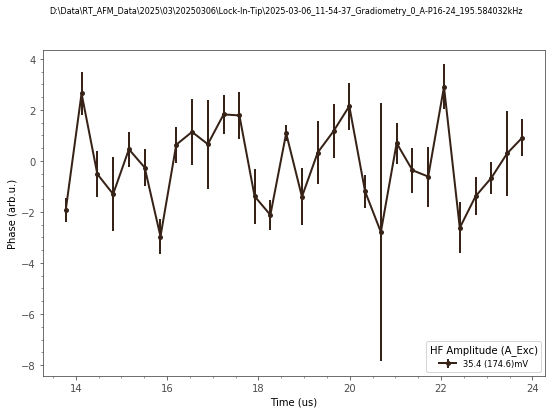

In [35]:
fig, ax1 = plt.subplots(1,1)

cm = plt.get_cmap('copper')
cl = cm(list(data.keys()))

for i, key in enumerate(data.keys()):
    t0_sweep = data[key]["t0_sweep"]*1e6
    data_raw = data[key]["data_raw"]
    rets = []
    for ind in range(data_raw.shape[1]):
        rets.append(analyse_sum(data_raw[:,ind,:]))
    
    cx = rets[0]
    cy = rets[1]
    cxa = rets[2]
    cya = rets[3]

    phase = []
    for ind in range(len(cx)):
        phase.append(umath.atan2((cya[ind]-cy[ind]),(cx[ind]-cxa[ind])))
    phase = np.array(phase)
    phase_nom = unumpy.nominal_values(phase)
    phase_err = unumpy.std_devs(phase)
    
    color = mpl.colors.rgb2hex(cl[i], keep_alpha=True)
    result = afm_scanner_logic._fitlogic.make_sine_fit(t0_sweep, phase_nom, estimator=afm_scanner_logic._fitlogic.estimate_sine)
    gmodel,_ = fitlogic.make_sine_model()

    ax1.errorbar(x=t0_sweep, 
                 y=phase_nom,
                 yerr=phase_err,
                 color=color,mec=color, 
                 label=f'{round(data[key]["HF_Ampl"]*1e3,1)} ({round(key*1e3,1)})mV', fmt='-o', markersize=5)
    t0_sweep_dense = np.linspace(t0_sweep[0], t0_sweep[-1], 500)
    temp = gmodel.eval(result.params, x=t0_sweep_dense)
#     ax1.plot(t0_sweep_dense, temp, 'k--')

    ax1.set_xlabel('Time (us)')
    ax1.set_ylabel('Phase (arb.u.)')
plt.legend(title="HF Amplitude (A_Exc)", loc=4, fontsize='small', fancybox=True)
fig.suptitle(f'{path}', fontsize=8)
# plt.savefig(path+'.png', dpi=900)
plt.show()

Define measurement params for lock in

In [6]:
#measurement parameters
laser_power_voltage = 0.1#podmrlogic.laser_power_voltage

#Driving information for the first LO (SMBV)
target_freq_0 = 3.108e9
LO_freq_0 = target_freq_0 + 100e6
power_0 = 5
pi_pulse = 260e-9 

#For same NV rabi SGS is run with power_1 = power_0 - 11dBm
#Driving information for the second LO (SGS)
target_freq_1 = 1/1.7e-6 # is used as mod freq
LO_freq_1 = 0
power_1 = 0
pi_pulse_1 = 0

switch_MW = False #If True, MW1 is used as the main MW source

#additional information for save tag
tip_name = 'A-P16-24'
sample = 'CoFeB'
temperature = 'RT'
b_field = 'mag_4mm'
contact = 'OOC'
extra = ''

 ... (more hidden) ...

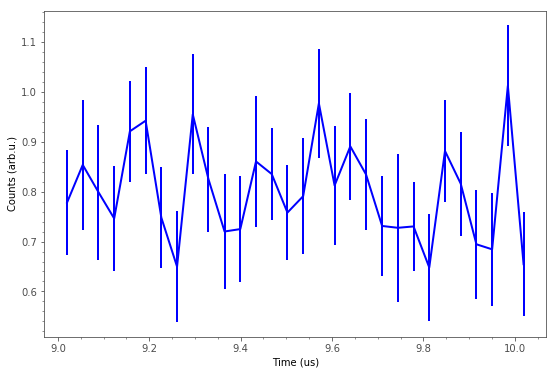

 ... (more hidden) ...


In [8]:
TF_Amp_arr = np.linspace(1,2,2)
TF_Amp = 0.4
res_freq = 32e3
hf_ampl = 0.144
trigger_level0 = 400
trigger_level1 = -200
wait_bw_TF_set = 0

# lift_off_height = 50e-9
lift_off_height_list = [50e-9]#np.linspace(10e-9, 50e-9, 6)
lift_off_check_period = 60*50

tau = 1.7e-6

t0_start = 10e-6
t0_stop = 11e-6
t0_num = 30
max_sweeps = 4e5

alternating = False
t0_sweep_init = np.linspace(t0_start, t0_stop, t0_num)
t0_sweep = np.zeros_like(t0_sweep_init)
c_x = np.zeros((len(t0_sweep_init),2))
c_x_alt = np.zeros((len(t0_sweep_init),2))
c_y = np.zeros((len(t0_sweep_init),2))
c_y_alt = np.zeros((len(t0_sweep_init),2))

phase_sweeps = np.zeros_like(t0_sweep_init)


afm_scanner_logic.jupyter_meas_stop = False

#setup_autoapproach()
#go_into_contact()

meas_dict = {}

for lift_off_height in lift_off_height_list:
#     spm._dev.afm.setTFExcitationAmplitude(TF_Amp)
#     time.sleep(wait_bw_TF_set)

    for i, t_0 in enumerate(tqdm(t0_sweep_init)):
        pjl.initialize_ensemble(laser_power_voltage = laser_power_voltage, pi_pulse=pi_pulse, 
                                pi_pulse_1=pi_pulse_1, LO_freq_0=LO_freq_0, target_freq_0=target_freq_0, 
                                power_0=power_0, LO_freq_1=LO_freq_1, target_freq_1=target_freq_1, power_1=power_1, 
                                switch_MW = switch_MW, trigger_type = 'none', trigger_level0 = trigger_level0, trigger_level1 = trigger_level1)

        ret = pjl.CPMG1_lock_in(t_0, tau, target_freq_1)
        t0_sweep[i] = ret[5]
#         print(ret[5]/1e-6, " - Actual T_0 time used in (us)")
        pulsedmeasurementlogic_AWG._PulsedMeasurementLogic__elapsed_sweeps = 0
    
        #Lift off
        lift_off_start = 0
        if lift_off_height > 0:
            #do_lift_off(lift_off_height)
            lift_off_start = time.time()
            
        pjl.start_measurement(measurement_type='CPMG1_gradiometry', tip_name=tip_name, sample=sample, 
                              temperature=temperature, b_field=b_field, contact=contact, extra=extra)

        while True and not afm_scanner_logic.jupyter_meas_stop:
            if abs(lift_off_start-time.time())>=lift_off_check_period and lift_off_height > 0 and lift_off_check_period > 0:
                pulsedmeasurementlogic_AWG.pause_pulsed_measurement()
                #go_into_contact()
                #do_lift_off(lift_off_height)
                lift_off_start = time.time()
                pulsedmeasurementlogic_AWG.continue_pulsed_measurement()
            
            if pulsedmasterlogic_AWG.elapsed_sweeps>max_sweeps:
                pulsedmeasurementlogic_AWG.stop_pulsed_measurement()
                c_x[i,:] = (pulsedmasterlogic_AWG.signal_data[1][0], pulsedmasterlogic_AWG.measurement_error[1][0])
                c_y[i,:] = (pulsedmasterlogic_AWG.signal_data[1][1], pulsedmasterlogic_AWG.measurement_error[1][1])
                c_x_alt[i,:] = (pulsedmasterlogic_AWG.signal_data[2][0], pulsedmasterlogic_AWG.measurement_error[2][0])
                c_y_alt[i,:] = (pulsedmasterlogic_AWG.signal_data[2][1], pulsedmasterlogic_AWG.measurement_error[2][1])
                
                phase_sweeps[i]  = pulsedmasterlogic_AWG.elapsed_sweeps
                break
            else:
                time.sleep(0.01)
                
        #go_into_contact()

        if afm_scanner_logic.jupyter_meas_stop:
            break


    meas_dict[lift_off_height] = {"t0_sweep": t0_sweep.copy(), "c_x": c_x.copy(), "c_y": c_y.copy(), "c_x_alt": c_x_alt.copy(), "c_y_alt": c_y_alt.copy(), "phase_sweeps": phase_sweeps.copy(), "lift_off_height":lift_off_height, "tau": tau}
    
    phase = np.arctan((c_y_alt[:,0]-c_y[:,0])/(c_x[:,0]-c_x_alt[:,0]))
    
    #for better reading
    a = c_y_alt[:,0]
    b = c_y[:,0]
    c = c_x[:,0]
    d = c_x_alt[:,0]
    phase_err = np.sqrt((((c-d)/((a-b)**2+(c-d)**2))*c_y_alt[:,1])**2
                        +(((d-c)/((a-b)**2+(c-d)**2))*c_y[:,1])**2
                        +(((b-a)/((a-b)**2+(c-d)**2))*c_x[:,1])**2
                        +(((a-b)/((a-b)**2+(c-d)**2))*c_x_alt[:,1])**2)
    fig, ax1 = plt.subplots(1,1)
    ax1.errorbar(x=t0_sweep/1e-6, y=phase,
                             yerr=phase_err, fmt='b-', label=f'')

    ax1.set_xlabel('Time (us)')
    ax1.set_ylabel('Counts (arb.u.)')

    plt.show()


    filelabel = tip_name + f"_{lift_off_height}"
    parameters = {'Res_freq':res_freq, 'A_exc':TF_Amp, 'Hf_ampl':hf_ampl, "Note": ""}
    data =  {'Time (us), Phase (arb.u.)Phase_err, Elapsed_sweeps': np.array((t0_sweep, phase, phase_err, phase_sweeps)).T}
    filepath = savelogic.get_path_for_module(module_name='Lock-In-Tip')
    savelogic.save_data(data, parameters=parameters, filepath=filepath, filelabel=filelabel, plotfig=fig, delimiter='\t')
# spm.retract_probe()
string = datetime.datetime.now().isoformat('_','seconds')+'_'+'CPMG1_gradiometry'+'_'+tip_name
filename = string.replace(':','-')
filepath = savelogic.get_path_for_module(module_name='Lock-In-Tip\\')

with open(filepath+filename+'.pickle', 'wb') as f:
    pickle.dump(meas_dict, f)